In [13]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('Border_Crossing_Entry_Data.csv')

df

,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Point
0,Jackman,Maine,104,US-Canada Border,Jan 2024,Trucks,6556,45.806,-70.397,POINT (-70.396722 45.805661)
1,Porthill,Idaho,3308,US-Canada Border,Apr 2024,Trucks,98,49.000,-116.499,POINT (-116.49925 48.999861)
2,San Luis,Arizona,2608,US-Mexico Border,Apr 2024,Buses,10,32.485,-114.782,POINT (-114.7822222 32.485)
3,Willow Creek,Montana,3325,US-Canada Border,Jan 2024,Pedestrians,2,49.000,-109.731,POINT (-109.731333 48.999972)
4,Warroad,Minnesota,3423,US-Canada Border,Jan 2024,Personal Vehicle Passengers,9266,48.999,-95.377,POINT (-95.376555 48.999)
...,...,...,...,...,...,...,...,...,...,...
406715,Opheim,Montana,3317,US-Canada Border,Dec 2025,Personal Vehicle Passengers,258,49.000,-106.378,POINT (-106.377583 48.999527)
406716,Lukeville,Arizona,2602,US-Mexico Border,Dec 2025,Personal Vehicles,26342,31.880,-112.817,POINT (-112.817077 31.880195)
406717,Vanceboro,Maine,105,US-Canada Border,Dec 2025,Rail Containers Empty,1052,45.569,-67.429,POINT (-67.428541 45.568761)
406718,Fort Fairfield,Maine,107,US-Canada Border,Dec 2025,Personal Vehicles,4912,46.765,-67.789,POINT (-67.789471 46.765323)


In [14]:
# Drop irrelevant columns
new_df = df.drop(columns=['Latitude', 'Longitude', 'Point'])
new_df

,Port Name,State,Port Code,Border,Date,Measure,Value
0,Jackman,Maine,104,US-Canada Border,Jan 2024,Trucks,6556
1,Porthill,Idaho,3308,US-Canada Border,Apr 2024,Trucks,98
2,San Luis,Arizona,2608,US-Mexico Border,Apr 2024,Buses,10
3,Willow Creek,Montana,3325,US-Canada Border,Jan 2024,Pedestrians,2
4,Warroad,Minnesota,3423,US-Canada Border,Jan 2024,Personal Vehicle Passengers,9266
...,...,...,...,...,...,...,...
406715,Opheim,Montana,3317,US-Canada Border,Dec 2025,Personal Vehicle Passengers,258
406716,Lukeville,Arizona,2602,US-Mexico Border,Dec 2025,Personal Vehicles,26342
406717,Vanceboro,Maine,105,US-Canada Border,Dec 2025,Rail Containers Empty,1052
406718,Fort Fairfield,Maine,107,US-Canada Border,Dec 2025,Personal Vehicles,4912


In [15]:
# Focus on California
new_df[new_df['State'] == 'California']

,Port Name,State,Port Code,Border,Date,Measure,Value
19,Calexico East,California,2507,US-Mexico Border,Jan 2024,Personal Vehicle Passengers,435768
82,Tecate,California,2505,US-Mexico Border,Jan 2024,Truck Containers Loaded,5306
99,Otay Mesa,California,2506,US-Mexico Border,Jan 2024,Truck Containers Loaded,101560
135,Calexico East,California,2507,US-Mexico Border,Jan 2024,Truck Containers Empty,18199
193,Calexico East,California,2507,US-Mexico Border,Jan 2024,Personal Vehicles,247739
...,...,...,...,...,...,...,...
406670,Otay Mesa,California,2506,US-Mexico Border,Dec 2025,Buses,1
406692,San Ysidro,California,2504,US-Mexico Border,Dec 2025,Pedestrians,662560
406694,Calexico East,California,2507,US-Mexico Border,Dec 2025,Truck Containers Empty,15204
406701,Otay Mesa,California,2506,US-Mexico Border,Dec 2025,Rail Containers Empty,90


In [25]:
# Inspect crossings for 2025, California border, Calexico East, and empty rail containers
crossings_last_year = new_df['Date'].str.contains('2025')
measure = new_df['Port Name'].str.contains('Calexico East')
cal_crossings = new_df['State'] == 'California'
empty_containers = new_df['Measure'] == 'Rail Containers Empty'
cal_crossings_last_year = new_df[crossings_last_year & cal_crossings & measure & empty_containers]
cal_crossings_last_year

,Port Name,State,Port Code,Border,Date,Measure,Value
398506,Calexico East,California,2507,US-Mexico Border,Jan 2025,Rail Containers Empty,1414
398847,Calexico East,California,2507,US-Mexico Border,Feb 2025,Rail Containers Empty,924
400147,Calexico East,California,2507,US-Mexico Border,Mar 2025,Rail Containers Empty,1060
400829,Calexico East,California,2507,US-Mexico Border,Apr 2025,Rail Containers Empty,1247
401282,Calexico East,California,2507,US-Mexico Border,May 2025,Rail Containers Empty,1151
401829,Calexico East,California,2507,US-Mexico Border,Jun 2025,Rail Containers Empty,1108
402787,Calexico East,California,2507,US-Mexico Border,Jul 2025,Rail Containers Empty,1176
403353,Calexico East,California,2507,US-Mexico Border,Aug 2025,Rail Containers Empty,1515
404260,Calexico East,California,2507,US-Mexico Border,Sep 2025,Rail Containers Empty,1432
405166,Calexico East,California,2507,US-Mexico Border,Oct 2025,Rail Containers Empty,860


Text(0, 0.5, 'Passenger Count')

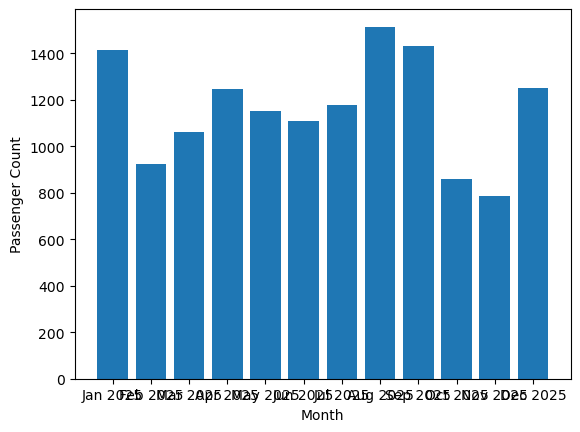

In [27]:
month = list(cal_crossings_last_year['Date'])
passenger_count = list(cal_crossings_last_year['Value'])

plt.bar(month, passenger_count)
plt.xlabel('Month')
plt.ylabel('Passenger Count')